In [1]:
!pip install -q gdown

In [2]:
!uv pip install mediapipe ultralytics

Using Python 3.12.13 environment at: /usr
Resolved 61 packages in 537ms
Prepared 5 packages in 385ms
Uninstalled 1 package in 4ms
Installed 5 packages in 21ms
 - absl-py==1.4.0
 + absl-py==2.5.0
 + mediapipe==0.10.35
 + sounddevice==0.5.5
 + ultralytics==8.4.96
 + ultralytics-thop==2.0.20


In [3]:
!gdown --fuzzy "https://drive.google.com/file/d/1ArAfaIW8MZovmdDIgvP-1ag8NyiVI1k9/view?usp=drive_link"

Downloading...
From (original): https://drive.google.com/uc?id=1ArAfaIW8MZovmdDIgvP-1ag8NyiVI1k9
From (redirected): https://drive.google.com/uc?id=1ArAfaIW8MZovmdDIgvP-1ag8NyiVI1k9&confirm=t&uuid=86e3ad36-b7cd-4434-963c-512c7b83b3ef
To: /content/yolo_dataset.zip
100% 1.03G/1.03G [00:15<00:00, 66.2MB/s]


In [4]:
!unzip -q yolo_dataset.zip

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Scaricamento modello MediaPipe...
Annotazione immagini in corso...
1315 immagini annotate correttamente in formato YOLO con classe unica (0).
File 'gestures.yaml' generato correttamente

Pulizia della cache di YOLO...
layer                                    name                type  gradient  parameters               shape        mu     sigma
    0                     model.0.conv.weight              Conv2d     False         432       [16, 3, 3, 3]  -0.00165      0.14        float32
    1                       model.0.bn.weight         BatchNorm2d     False          16                [16]      3.07       1.9        float32
    1                         model.0.bn.bias         Bat

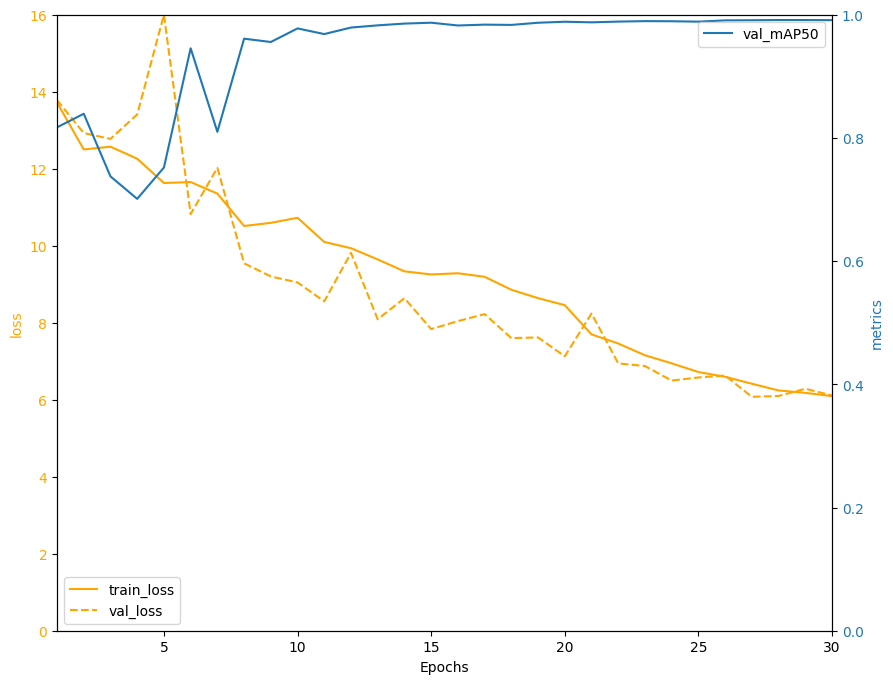

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


0: 640x640 1 hand, 9.4ms
1: 640x640 1 hand, 9.4ms
2: 640x640 1 hand, 9.4ms
3: 640x640 1 hand, 9.4ms
4: 640x640 2 hands, 9.4ms
Speed: 2.0ms preprocess, 9.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [5]:
import os
import cv2
import shutil
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import glob
import random

YOLO_DIR = "yolo_dataset"
EPOCHS = 30
PATIENCE = 5

def extract_history(model):
  df = pd.read_csv(model.trainer.csv)

  box_w=model.trainer.args.box
  cls_w=model.trainer.args.cls
  dfl_w=model.trainer.args.dfl

  history=  {
              "train_loss" : box_w*df["train/box_loss"] + cls_w*df["train/cls_loss"] + dfl_w*df["train/dfl_loss"],
              "val_loss" : box_w*df["val/box_loss"] + cls_w*df["val/cls_loss"] + dfl_w*df["val/dfl_loss"],
              "val_precision" : df["metrics/precision(B)"],
              "val_recall" : df["metrics/recall(B)"],
              "val_mAP50" : df["metrics/mAP50(B)"],
              "val_mAP50-95" : df["metrics/mAP50-95(B)"],
            }

  return history

def plot_history(history):
  fig, ax1 = plt.subplots(figsize=(10, 8))

  epoch_count=len(history["train_loss"])

  line1,=ax1.plot(range(1,epoch_count+1),history["train_loss"],label="train_loss",color="orange")
  ax1.plot(range(1,epoch_count+1),history["val_loss"],label="val_loss",color = line1.get_color(), linestyle = '--')
  ax1.set_xlim([1,epoch_count])
  ax1.set_ylim([0, max(max(history["train_loss"]),max(history["val_loss"]))])
  ax1.set_ylabel("loss",color = line1.get_color())
  ax1.tick_params(axis="y", labelcolor=line1.get_color())
  ax1.set_xlabel("Epochs")
  _=ax1.legend(loc="lower left")

  ax2 = ax1.twinx()
  line2,=ax2.plot(range(1,epoch_count+1),history["val_mAP50"],label="val_mAP50")
  ax2.set_ylim([0, 1])
  ax2.set_ylabel("metrics",color=line2.get_color())
  ax2.tick_params(axis="y", labelcolor=line2.get_color())
  _=ax2.legend(loc="upper right")
  plt.show()

os.makedirs(f"{YOLO_DIR}/images/train", exist_ok=True)
os.makedirs(f"{YOLO_DIR}/labels/train", exist_ok=True)

model_path = 'hand_landmarker.task'
if not os.path.exists(model_path):
    print("Scaricamento modello MediaPipe...")
    urllib.request.urlretrieve("https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task", model_path)

options = vision.HandLandmarkerOptions(base_options=python.BaseOptions(model_asset_path=model_path), num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)

immagini_salvate = 0

cartella_immagini = os.path.join(YOLO_DIR, "images/train")
cartella_labels = os.path.join(YOLO_DIR, "labels/train")

print("Annotazione immagini in corso...")

for file_name in os.listdir(cartella_immagini):
    if not file_name.endswith(('.jpg', '.png', '.jpeg')): continue

    img_path = os.path.join(cartella_immagini, file_name)
    img = cv2.imread(img_path)
    if img is None: continue

    h, w, _ = img.shape
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results = detector.detect(mp_image)

    if results.hand_landmarks:
        landmarks = results.hand_landmarks[0]

        x_coords = [lm.x for lm in landmarks]
        y_coords = [lm.y for lm in landmarks]

        x_center = (max(x_coords) + min(x_coords)) / 2.0
        y_center = (max(y_coords) + min(y_coords)) / 2.0

        box_w = min(max(x_coords) - min(x_coords) + 0.05, 1.0)
        box_h = min(max(y_coords) - min(y_coords) + 0.05, 1.0)

        label_name = file_name.rsplit('.', 1)[0] + ".txt"
        with open(os.path.join(cartella_labels, label_name), "w") as f:
            f.write(f"0 {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}\n")

        immagini_salvate += 1

print(f"{immagini_salvate} immagini annotate correttamente in formato YOLO con classe unica (0).")

percorso_assoluto = os.path.abspath(YOLO_DIR).replace("\\", "/")
yaml_content = f"""
path: {percorso_assoluto}
train: images/train
val: images/train

names:
  0: hand
"""
yaml_path = "gestures.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content.strip())
print(f"File '{yaml_path}' generato correttamente")


print("\nPulizia della cache di YOLO...")
cache_files = glob.glob(os.path.join(YOLO_DIR, "labels/train/*.cache"))
for cache_file in cache_files:
    os.remove(cache_file)
    print(f"  -> File cache eliminato: {cache_file}")


yolo_detector = YOLO("yolo11n.pt")

yolo_detector.info(detailed=True)

results = yolo_detector.train(
    data=yaml_path,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=False,
    workers=4
)

history=extract_history(yolo_detector)

plot_history(history)

yolo_detector.eval()
tutte_le_immagini = glob.glob(f"{YOLO_DIR}/images/train/*.*")

if len(tutte_le_immagini) > 0:
    immagini_di_test = random.sample(tutte_le_immagini, min(5, len(tutte_le_immagini)))
    results = yolo_detector.predict(source=immagini_di_test, save=True, show=True)

In [6]:
import math
import os
import cv2
import shutil
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import glob
import random

In [7]:
def plot_results(results,image_per_row=4,show_labels=True):
  image_count=len(results)
  row_count=math.ceil(image_count/image_per_row)
  col_count=image_per_row

  _, axs = plt.subplots(nrows=row_count, ncols=col_count,figsize=(18, 4*row_count),squeeze=False)
  for r in range(row_count):
      for c in range(col_count):
        axs[r,c].axis("off")

  for i in range(image_count):
    r = i // image_per_row
    c = i % image_per_row

    axs[r,c].imshow(results[i].plot(labels=show_labels))

In [9]:
yolo_detector = YOLO("runs/detect/train/weights/best.pt")
GESTURE_CLASSES = ['open_palm', 'fist', 'index', 'two_fingers', 'pinch']
SOURCE_DIR = "dataset/train"
YOLO_DIR = "yolo_dataset"
EPOCHS = 30
PATIENCE = 5
tutte_le_immagini = glob.glob(f"{YOLO_DIR}/images/train/*.*")
immagini_di_test = random.sample(tutte_le_immagini, min(5, len(tutte_le_immagini)))
results = yolo_detector.predict(source=immagini_di_test, save=True, show=True)


0: 640x640 1 hand, 5.5ms
1: 640x640 1 hand, 5.5ms
2: 640x640 2 hands, 5.5ms
3: 640x640 1 hand, 5.5ms
4: 640x640 2 hands, 5.5ms
Speed: 3.0ms preprocess, 5.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


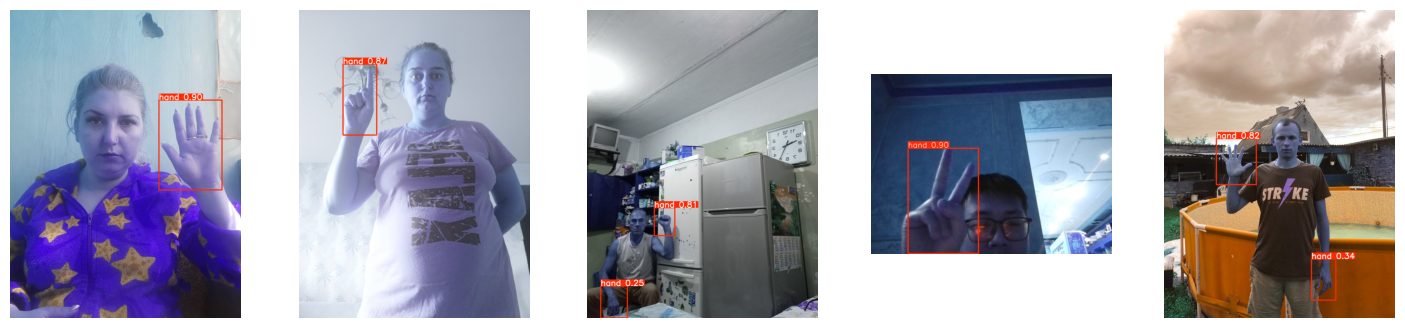

In [10]:
plot_results(results,image_per_row=5,show_labels=True)